In [1]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA 사용 가능:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.31  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Setup complete  (16 CPUs, 31.7 GB RAM, 179.0/475.9 GB disk)


In [3]:
import torch
import cv2
import ultralytics
import roboflow
import inference_sdk

In [4]:
print("openCV:", cv2.__version__)
print("ultralytics:", ultralytics.__version__)

openCV: 4.10.0
ultralytics: 8.4.31


# 로보플로 인퍼런스 api 사용하기 

In [ ]:
from inference_sdk import InferenceHTTPClient

CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="RqQEBE0zpu0utPao2x59"
)

result = CLIENT.infer('rps.jpg', model_id="rock-paper-scissors-sxsw/14")

In [9]:
print(result)

{'inference_id': 'bc05dd31-6667-4397-b086-7354f51f23c4', 'time': 0.008195063099265099, 'image': {'width': 257, 'height': 196}, 'predictions': [{'x': 174.5, 'y': 149.0, 'width': 65.0, 'height': 68.0, 'confidence': 0.9275731444358826, 'class': 'Rock', 'class_id': 1, 'detection_id': '2ea6ed3b-eab1-4625-a053-235fbfb603cb'}, {'x': 65.5, 'y': 143.0, 'width': 123.0, 'height': 84.0, 'confidence': 0.8793544769287109, 'class': 'Scissors', 'class_id': 2, 'detection_id': 'c245375a-d13e-4616-8242-4a1a734c2529'}, {'x': 189.5, 'y': 53.0, 'width': 117.0, 'height': 86.0, 'confidence': 0.8583617210388184, 'class': 'Scissors', 'class_id': 2, 'detection_id': '50cc3744-8913-4593-ac9a-cefd4bc33a7e'}]}


In [10]:
# 이미지 시각화

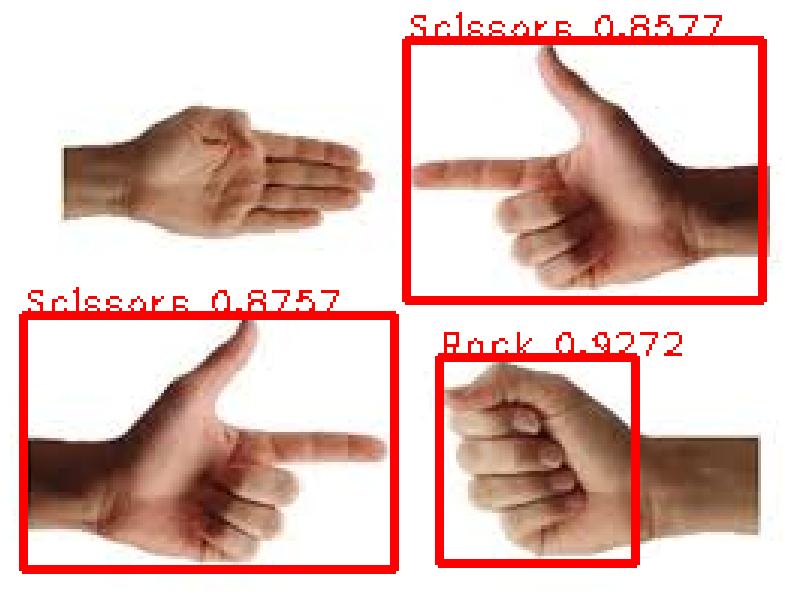

In [18]:
import cv2
import matplotlib.pyplot as plt

filename = 'rps.jpg'
result = CLIENT.infer('rps.jpg', model_id="rock-paper-scissors-sxsw/14")
img = cv2.imread('rps.jpg')

for pred in result["predictions"]:
    x, y = pred['x'], pred['y']
    width, height = pred['width'], pred['height']
    conf = pred['confidence']
    cls = pred['class']
    x1, y1 = int(x-width/2), int(y-height/2)
    x2, y2 = int(x+width/2), int(y+height/2)
    cv2.rectangle(img, (x1,y1), (x2, y2), (0,0,255), 2)
    cv2.putText(img, f'{cls} {conf:.4f}', (x1,y1), cv2.FONT_HERSHEY_PLAIN, 0.8, (0,0,255))

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

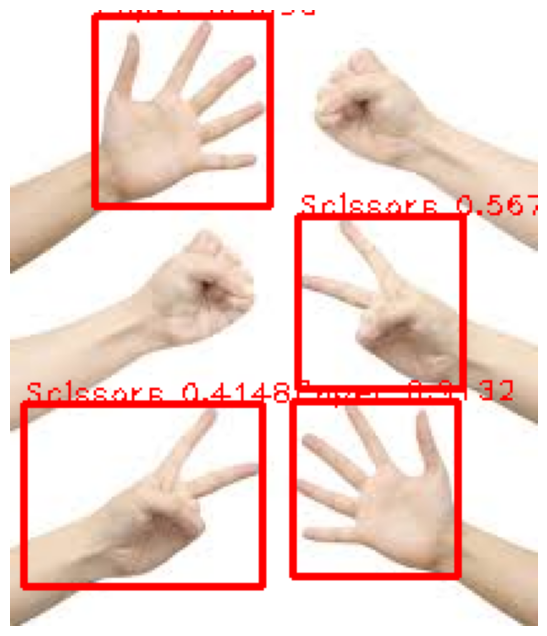

In [17]:
import cv2
import matplotlib.pyplot as plt

filename = '다운로드 (1).jpg'
result = CLIENT.infer('다운로드 (1).jpg', model_id="rock-paper-scissors-sxsw/14")
img = cv2.imread('다운로드 (1).jpg')

for pred in result["predictions"]:
    x, y = pred['x'], pred['y']
    width, height = pred['width'], pred['height']
    conf = pred['confidence']
    cls = pred['class']
    x1, y1 = int(x-width/2), int(y-height/2)
    x2, y2 = int(x+width/2), int(y+height/2)
    cv2.rectangle(img, (x1,y1), (x2, y2), (0,0,255), 2)
    cv2.putText(img, f'{cls} {conf:.4f}', (x1,y1), cv2.FONT_HERSHEY_PLAIN, 0.8, (0,0,255))

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()